In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
df= pd.read_csv(r"C:\Users\Asus vivobook\Downloads\stocks.csv")

In [3]:
df


,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000
...,...,...,...,...,...,...,...,...
243,GOOG,2023-05-01,107.720001,108.680000,107.500000,107.709999,107.709999,20926300
244,GOOG,2023-05-02,107.660004,107.730003,104.500000,105.980003,105.980003,20343100
245,GOOG,2023-05-03,106.220001,108.129997,105.620003,106.120003,106.120003,17116300
246,GOOG,2023-05-04,106.160004,106.300003,104.699997,105.209999,105.209999,19780600


In [5]:
df.columns

Index(['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close',
       'Volume'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    str    
 1   Date       248 non-null    str    
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), str(2)
memory usage: 15.6 KB


In [7]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,248.000000,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,215.252093,217.919662,212.697452,215.381674,215.362697,3.208210e+07
std,91.691315,92.863023,90.147881,91.461989,91.454750,2.233590e+07
min,89.540001,90.129997,88.860001,89.349998,89.349998,2.657900e+06
25%,135.235004,137.440004,134.822495,136.347498,136.347498,1.714180e+07
50%,208.764999,212.614998,208.184998,209.920006,209.920006,2.734000e+07
75%,304.177505,307.565002,295.437500,303.942505,303.942505,4.771772e+07
max,372.410004,373.829987,361.739990,366.829987,366.829987,1.133164e+08


DATA CLEANING 

In [12]:
df.isnull().sum()

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['Date'] = pd.to_datetime(df['Date'])
df

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000
...,...,...,...,...,...,...,...,...
243,GOOG,2023-05-01,107.720001,108.680000,107.500000,107.709999,107.709999,20926300
244,GOOG,2023-05-02,107.660004,107.730003,104.500000,105.980003,105.980003,20343100
245,GOOG,2023-05-03,106.220001,108.129997,105.620003,106.120003,106.120003,17116300
246,GOOG,2023-05-04,106.160004,106.300003,104.699997,105.209999,105.209999,19780600


In [17]:
df['Open'].mean().__round__(2)

np.float64(215.25)

In [18]:
df['Close'].mean().__round__(2)

np.float64(215.38)

In [19]:
df['High'].mean().__round__(2)

np.float64(217.92)

In [20]:
df['Low'].mean().__round__(2)

np.float64(212.7)

In [25]:
df['Volume'].mean().__round__(2)

np.float64(32082104.03)

Daily Price Change

In [27]:
df['Price Change'] = df['Close'] - df['Open']
df['Price Change']

0      4.009995
1     -1.960007
2     -2.910004
3      1.549988
4      2.900009
         ...   
243   -0.010002
244   -1.680000
245   -0.099998
246   -0.950005
247    0.894997
Name: Price Change, Length: 248, dtype: float64

Daily Return (%)

In [56]:
df['Daily Return %'] = ((df['Close']-df['Open'])/df['Open'])*100
df['Daily Return %'].round(2)

0      2.66
1     -1.27
2     -1.89
3      1.04
4      1.92
       ... 
243   -0.01
244   -1.56
245   -0.09
246   -0.89
247    0.85
Name: Daily Return %, Length: 248, dtype: float64

Price Volatility

In [57]:
df['Volatility'] = df['High'] - df['Low']
df['Volatility'].round(2)

0      4.59
1      3.41
2      3.91
3      2.12
4      3.34
       ... 
243    1.18
244    3.23
245    2.51
246    1.60
247    1.70
Name: Volatility, Length: 248, dtype: float64

Company-wise Analysis

In [58]:
df.groupby('Ticker')['Close'].mean().round(2)

Ticker
AAPL    158.24
GOOG    100.63
MSFT    275.04
NFLX    327.61
Name: Close, dtype: float64

In [59]:
df.groupby('Ticker')['Open'].mean().round(2)

Ticker
AAPL    157.78
GOOG    100.38
MSFT    274.74
NFLX    328.11
Name: Open, dtype: float64

In [60]:
df.groupby('Ticker')['Volume'].mean().round(2)

Ticker
AAPL    60282958.06
GOOG    30725372.58
MSFT    30848353.23
NFLX     6471732.26
Name: Volume, dtype: float64

In [61]:
df.groupby('Ticker')['High'].mean().round(2)

Ticker
AAPL    159.47
GOOG    101.79
MSFT    277.76
NFLX    332.65
Name: High, dtype: float64

In [62]:
df.groupby('Ticker')['Low'].mean().round(2)

Ticker
AAPL    156.67
GOOG     99.26
MSFT    272.03
NFLX    322.83
Name: Low, dtype: float64

COREELATION ANALYSIS

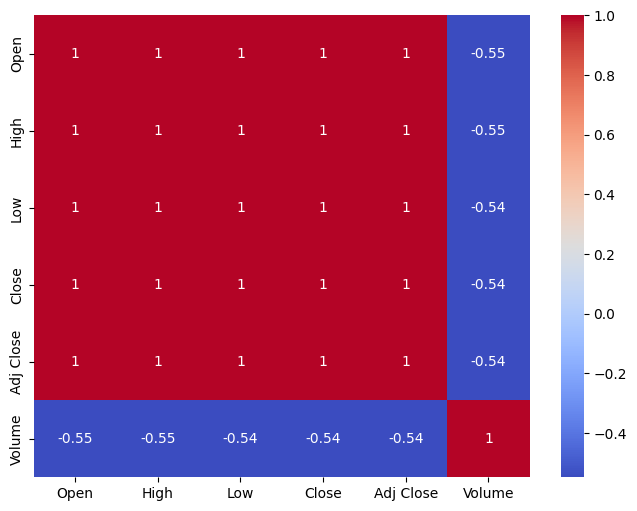

In [63]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Open','High','Low','Close','Adj Close','Volume']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

Trend Analysis

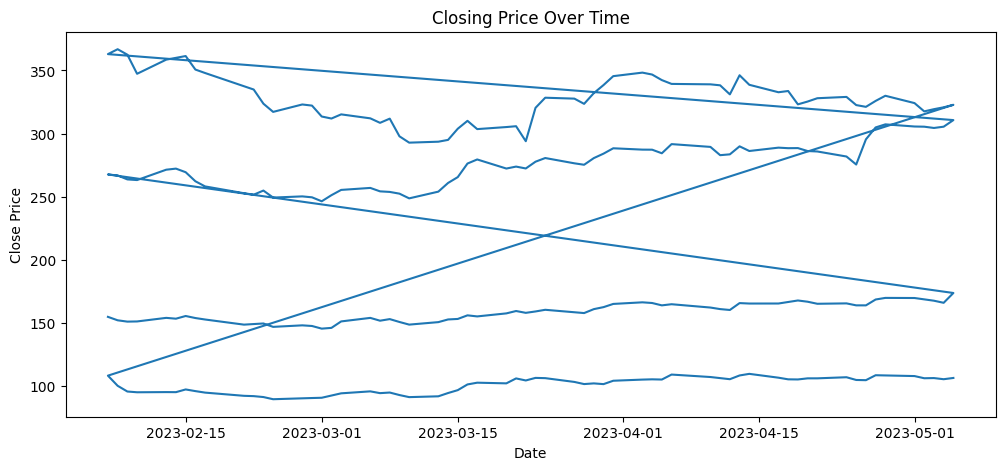

In [64]:


plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Close'])

plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

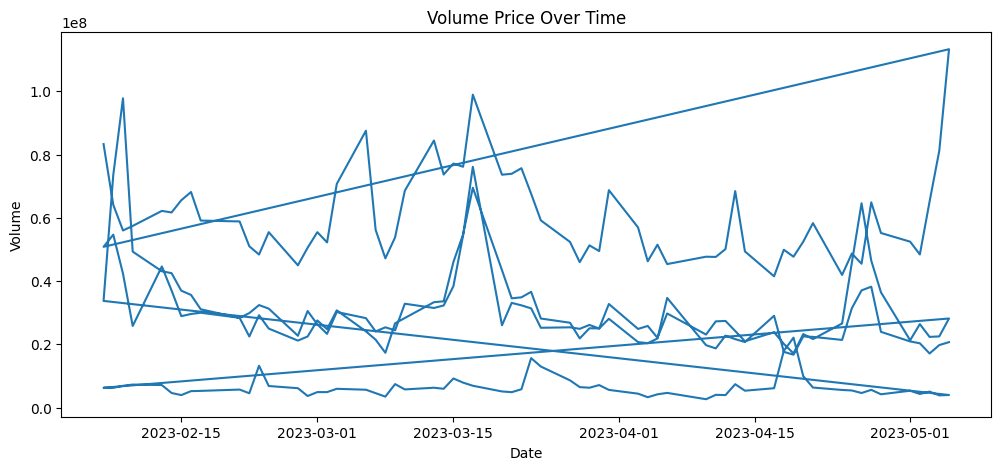

In [65]:

plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Volume'])

plt.title("Volume Price Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

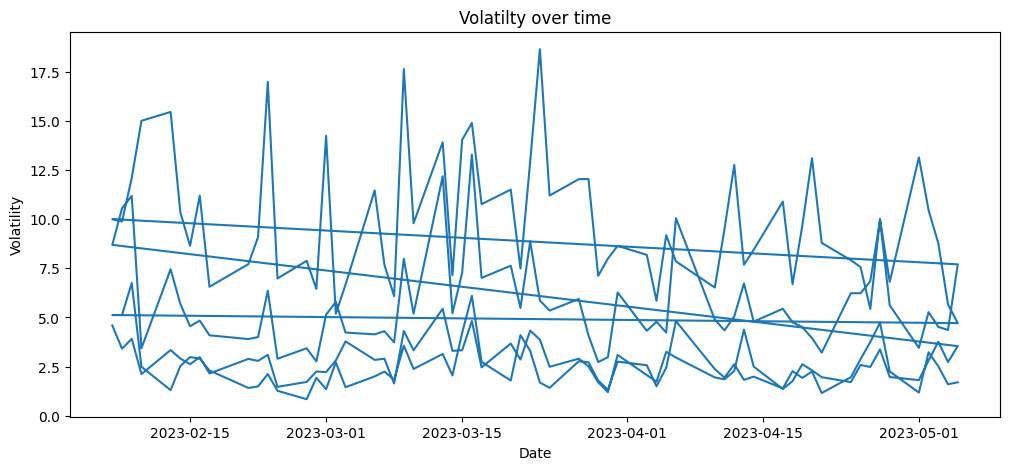

In [66]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'],df['Volatility'])
plt.title('Volatilty over time')
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

Univariate Analysis

Distribution of Closing Price

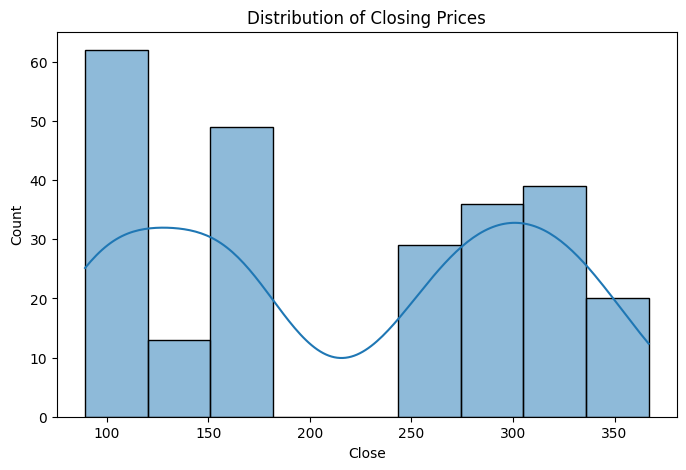

In [67]:
plt.figure(figsize=(8,5))
sns.histplot(df['Close'], kde=True)
plt.title("Distribution of Closing Prices")
plt.show()

Distribution of Trading Volume

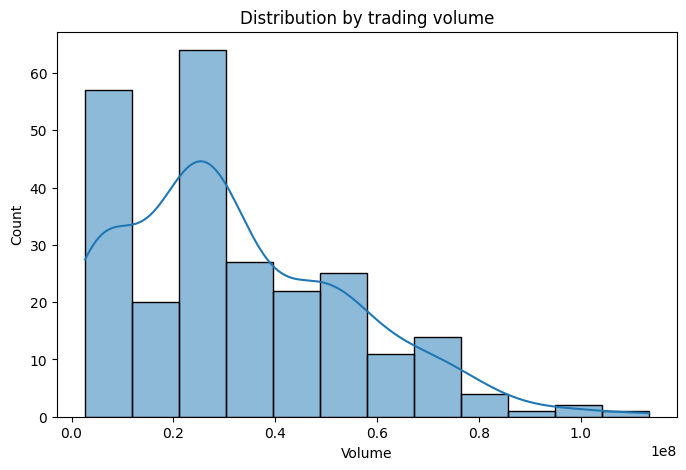

In [68]:
plt.figure(figsize=(8,5))
sns.histplot(df['Volume'], kde=True)
plt.title("Distribution by trading volume")
plt.show()


Boxplots (Outlier Detection)





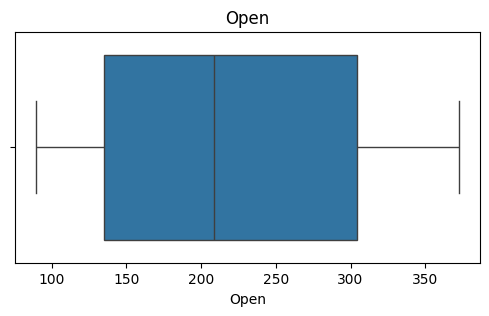

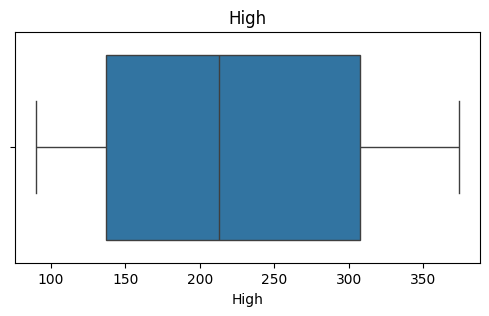

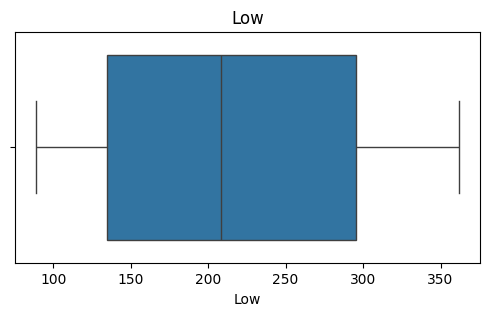

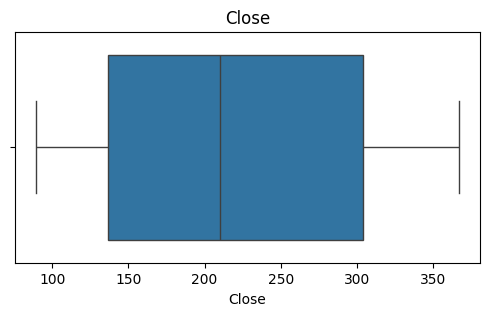

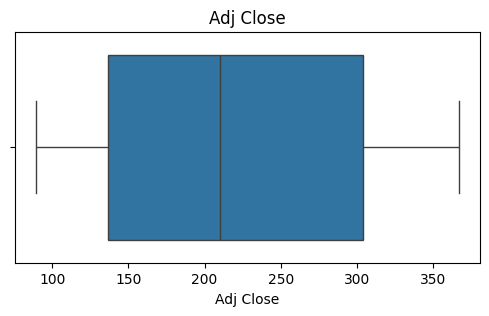

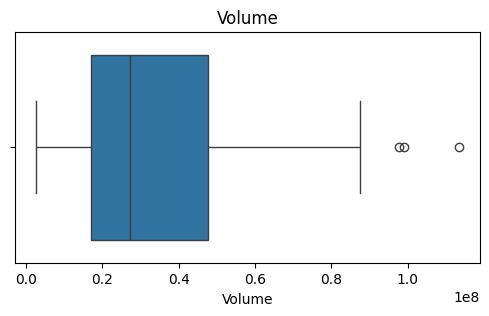

In [69]:
cols = ['Open','High','Low','Close','Adj Close','Volume']

for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Scatter Plot (Volume vs Close)

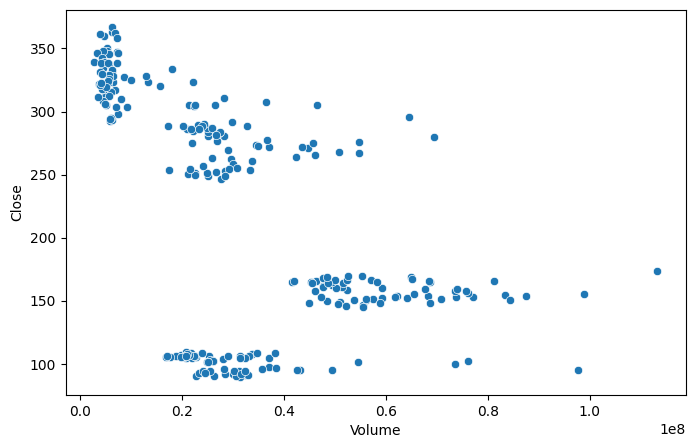

In [70]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x='Volume',y='Close')

plt.show()

moving average

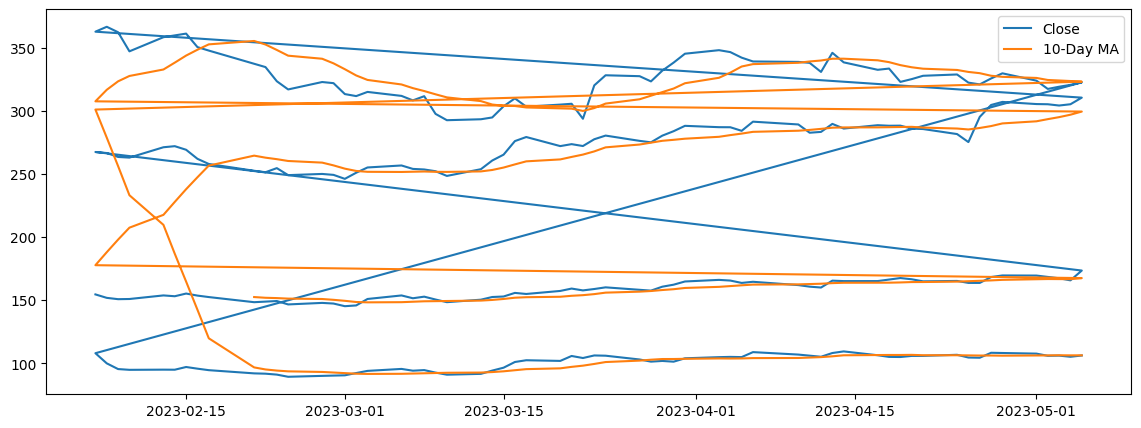

In [71]:
df['MA10'] = df['Close'].rolling(10).mean()

plt.figure(figsize=(14,5))

plt.plot(df['Date'],df['Close'],label='Close')
plt.plot(df['Date'],df['MA10'],label='10-Day MA')

plt.legend()
plt.show()

Best and Worst days

In [74]:
df.loc[df['Daily Return %'].idxmax()]

Ticker                           NFLX
Date              2023-03-23 00:00:00
Open                       304.679993
High                       322.779999
Low                        304.140015
Close                      320.369995
Adj Close                  320.369995
Volume                       15653300
Price Change                15.690002
Daily Return %               5.149666
Volatility                  18.639984
MA10                       302.375003
Name: 155, dtype: object

In [75]:
df.loc[df['Daily Return %'].idxmin()]

Ticker                           GOOG
Date              2023-02-09 00:00:00
Open                       100.540001
High                       100.610001
Low                         93.860001
Close                       95.459999
Adj Close                   95.459999
Volume                       97798600
Price Change                -5.080002
Daily Return %              -5.052717
Volatility                       6.75
MA10                       256.378998
Name: 188, dtype: object